# COCO Image Captioning with ViT Encoder + Transformer Decoder

A small educational image-captioning project built entirely around Transformer components:

- **Image encoder:** pretrained Vision Transformer (ViT-B/16)
- **Text decoder:** PyTorch Transformer Decoder
- **Dataset:** 2,000 images from COCO 2017 validation
- **Evaluation:** BLEU-1 and BLEU-4

This is a baseline educational experiment and is not intended to achieve state-of-the-art performance.


## 1. Install dependencies


In [ ]:
!pip -q install datasets nltk tqdm


## 2. Imports and configuration


In [5]:
import re
import json
import math
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from datasets import load_dataset


# =========================
# 1. Reproducibility
# =========================

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


# =========================
# 2. Dataset Configuration
# =========================

NUM_IMAGES = 1500

# Training configuration
BATCH_SIZE = 16
NUM_EPOCHS = 7
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

MAX_LENGTH = 25
MIN_FREQ = 2
NUM_WORKERS = 0


# =========================
# 3. Transformer Decoder
# =========================

D_MODEL = 256
NHEAD = 8
NUM_DECODER_LAYERS = 3
DIM_FEEDFORWARD = 512
DROPOUT = 0.2


# =========================
# 4. Dataset Paths
# =========================

DATA_DIR = Path("/content/data")
IMAGE_DIR = DATA_DIR / "val2017"
CSV_PATH = DATA_DIR / "captions.csv"


# =========================
# 5. Model Artifacts
# =========================

ARTIFACT_DIR = Path("/content/artifacts_vit_transformer")

CHECKPOINT_PATH = ARTIFACT_DIR / "best_vit_transformer_model.pt"
VOCAB_PATH = ARTIFACT_DIR / "vocab.json"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 6. Device Configuration
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will use CPU.")


# =========================
# 7. Display Configuration
# =========================

print("\nExperiment Configuration")
print("-" * 35)
print("Number of images:", NUM_IMAGES)
print("Batch size:", BATCH_SIZE)
print("Number of epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Maximum caption length:", MAX_LENGTH)
print("Transformer decoder layers:", NUM_DECODER_LAYERS)
print("Device:", device)
print("Checkpoint path:", CHECKPOINT_PATH)
print("Vocabulary path:", VOCAB_PATH)

Device: cuda
GPU: Tesla T4

Experiment Configuration
-----------------------------------
Number of images: 1500
Batch size: 16
Number of epochs: 7
Learning rate: 0.0003
Maximum caption length: 25
Transformer decoder layers: 3
Device: cuda
Checkpoint path: /content/artifacts_vit_transformer/best_vit_transformer_model.pt
Vocabulary path: /content/artifacts_vit_transformer/vocab.json


## 3. Download COCO images

The COCO validation archive contains 5,000 images. The notebook later selects 2,000 images and all their captions.


In [6]:
if not IMAGE_DIR.exists() or len(list(IMAGE_DIR.glob("*.jpg"))) < 5000:
    print("Downloading COCO val2017 images...")
    !wget -q --show-progress -O /content/val2017.zip http://images.cocodataset.org/zips/val2017.zip

    print("Extracting images...")
    !unzip -q -o /content/val2017.zip -d /content/data
else:
    print("COCO images already exist.")

available_images = len(list(IMAGE_DIR.glob("*.jpg")))
print("Available images:", available_images)

if available_images < NUM_IMAGES:
    raise RuntimeError("Not enough COCO images were found.")


COCO images already exist.
Available images: 5000


## 4. Build the image-caption CSV


In [7]:
def create_caption_csv():
    metadata = load_dataset(
        "phiyodr/coco2017",
        split="validation"
    )

    metadata = metadata.shuffle(seed=SEED).select(range(NUM_IMAGES))

    rows = []

    for sample in tqdm(metadata, desc="Preparing captions"):
        filename = Path(sample["file_name"]).name
        image_path = IMAGE_DIR / filename

        if not image_path.exists():
            continue

        for caption in sample["captions"]:
            caption = str(caption).strip()

            if caption:
                rows.append({
                    "image_id": int(sample["image_id"]),
                    "image": filename,
                    "caption": caption
                })

    dataframe = pd.DataFrame(rows)

    if dataframe.empty:
        raise RuntimeError("No image-caption pairs were created.")

    dataframe.to_csv(CSV_PATH, index=False)
    return dataframe


if CSV_PATH.exists():
    captions_df = pd.read_csv(CSV_PATH)

    if captions_df["image_id"].nunique() != NUM_IMAGES:
        captions_df = create_caption_csv()
else:
    captions_df = create_caption_csv()

print("Caption rows:", len(captions_df))
print("Unique images:", captions_df["image_id"].nunique())
print("CSV path:", CSV_PATH)

captions_df.head()


Caption rows: 7504
Unique images: 1500
CSV path: /content/data/captions.csv


,image_id,image,caption
0,5477,000000005477.jpg,large mustard yellow commercial airplane parke...
1,5477,000000005477.jpg,A brown jetliner sitting on top of an airport ...
2,5477,000000005477.jpg,A brown LOT airliner sitting on the tarmac
3,5477,000000005477.jpg,"A gold colored, Polish airplane sitting on the..."
4,5477,000000005477.jpg,A large golden airplane is on the runway.


## 5. Split by image ID



In [8]:
# Split dataset by image ID to prevent data leakage

image_ids = (
    captions_df["image_id"]
    .drop_duplicates()
    .sample(frac=1, random_state=SEED)
    .tolist()
)

number_of_images = len(image_ids)

# 80% training, 10% validation, 10% testing
train_end = int(0.80 * number_of_images)
valid_end = int(0.90 * number_of_images)

train_ids = set(image_ids[:train_end])
valid_ids = set(image_ids[train_end:valid_end])
test_ids = set(image_ids[valid_end:])

# Create separate DataFrames
train_df = captions_df[
    captions_df["image_id"].isin(train_ids)
].reset_index(drop=True)

valid_df = captions_df[
    captions_df["image_id"].isin(valid_ids)
].reset_index(drop=True)

test_df = captions_df[
    captions_df["image_id"].isin(test_ids)
].reset_index(drop=True)

# Display split information
print(
    "Train images:", train_df["image_id"].nunique(),
    "| captions:", len(train_df)
)

print(
    "Validation images:", valid_df["image_id"].nunique(),
    "| captions:", len(valid_df)
)

print(
    "Test images:", test_df["image_id"].nunique(),
    "| captions:", len(test_df)
)

# Verify that image IDs do not overlap between splits
assert train_ids.isdisjoint(valid_ids)
assert train_ids.isdisjoint(test_ids)
assert valid_ids.isdisjoint(test_ids)

print("\nDataset split verified: No image-ID overlap.")

Train images: 1200 | captions: 6003
Validation images: 150 | captions: 751
Test images: 150 | captions: 750

Dataset split verified: No image-ID overlap.


## 6. Tokenizer and vocabulary


In [9]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>"]

def tokenize(text):
    return re.findall(r"[a-z0-9']+", str(text).lower())


class Vocabulary:
    def __init__(self, captions=None, min_freq=2, stoi=None):
        if stoi is not None:
            self.stoi = stoi
        else:
            counter = Counter()

            for caption in captions:
                counter.update(tokenize(caption))

            words = sorted(
                word
                for word, frequency in counter.items()
                if frequency >= min_freq
            )

            self.stoi = {
                token: index
                for index, token in enumerate(SPECIAL_TOKENS + words)
            }

        self.itos = {
            index: token
            for token, index in self.stoi.items()
        }

    def __len__(self):
        return len(self.stoi)

    @property
    def pad_index(self):
        return self.stoi["<pad>"]

    @property
    def sos_index(self):
        return self.stoi["<sos>"]

    @property
    def eos_index(self):
        return self.stoi["<eos>"]

    @property
    def unk_index(self):
        return self.stoi["<unk>"]

    def encode(self, caption):
        tokens = (
            ["<sos>"]
            + tokenize(caption)[:MAX_LENGTH - 2]
            + ["<eos>"]
        )

        return torch.tensor(
            [
                self.stoi.get(token, self.unk_index)
                for token in tokens
            ],
            dtype=torch.long
        )

    def decode(self, indices):
        words = []

        for index in indices:
            token = self.itos.get(int(index), "<unk>")

            if token == "<eos>":
                break

            if token not in {"<sos>", "<pad>"}:
                words.append(token)

        return " ".join(words)


vocab = Vocabulary(
    captions=train_df["caption"].tolist(),
    min_freq=MIN_FREQ
)

VOCAB_PATH.write_text(
    json.dumps(vocab.stoi, indent=2),
    encoding="utf-8"
)

print("Vocabulary size:", len(vocab))


Vocabulary size: 2049


## 7. Dataset and DataLoaders


In [10]:
# ViT-B/16 pretrained weights expect ImageNet normalization.
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class CocoCaptionDataset(Dataset):
    def __init__(self, dataframe, image_dir, vocabulary, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.vocab = vocabulary
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(
            self.image_dir / row["image"]
        ).convert("RGB")

        image = self.transform(image)
        caption = self.vocab.encode(row["caption"])

        return image, caption


def make_collate_fn(pad_index):
    def collate(batch):
        images, captions = zip(*batch)

        images = torch.stack(images)

        captions = pad_sequence(
            captions,
            batch_first=True,
            padding_value=pad_index
        )

        return images, captions

    return collate


collate_fn = make_collate_fn(vocab.pad_index)

train_set = CocoCaptionDataset(
    train_df, IMAGE_DIR, vocab, train_transform
)

valid_set = CocoCaptionDataset(
    valid_df, IMAGE_DIR, vocab, eval_transform
)

test_set = CocoCaptionDataset(
    test_df, IMAGE_DIR, vocab, eval_transform
)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

images, captions = next(iter(train_loader))

print("Image batch:", images.shape)
print("Caption batch:", captions.shape)


Image batch: torch.Size([16, 3, 224, 224])
Caption batch: torch.Size([16, 16])


## 8. ViT encoder + Transformer decoder

ViT-B/16 divides each 224×224 image into 16×16 patches:

- 14 × 14 = **196 image patches**
- each patch becomes a visual token
- the Transformer decoder attends to these visual tokens while generating words

The pretrained ViT encoder is frozen to keep the experiment feasible on a Colab T4 GPU.


In [11]:
class ViTImageEncoder(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.vit = vit_b_16(
            weights=ViT_B_16_Weights.IMAGENET1K_V1
        )

        # Remove the classification head because we need token features.
        self.vit.heads = nn.Identity()

        for parameter in self.vit.parameters():
            parameter.requires_grad = False

        # ViT-B/16 hidden dimension is 768.
        self.projection = nn.Linear(
            768,
            d_model
        )

        self.layer_norm = nn.LayerNorm(
            d_model
        )

    def forward(self, images):
        self.vit.eval()

        with torch.no_grad():
            # Patchify image: [B, 196, 768]
            patch_tokens = self.vit._process_input(images)

            batch_size = patch_tokens.shape[0]

            class_token = self.vit.class_token.expand(
                batch_size,
                -1,
                -1
            )

            tokens = torch.cat(
                [class_token, patch_tokens],
                dim=1
            )

            # Run the pretrained ViT Transformer encoder.
            encoded_tokens = self.vit.encoder(tokens)

            # Exclude the class token and retain 196 patch tokens.
            patch_features = encoded_tokens[:, 1:, :]

        patch_features = self.projection(
            patch_features
        )

        return self.layer_norm(
            patch_features
        )


class TransformerTextDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        nhead,
        num_layers,
        dim_feedforward,
        dropout,
        max_length,
        pad_index
    ):
        super().__init__()

        self.d_model = d_model
        self.max_length = max_length
        self.pad_index = pad_index

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_index
        )

        self.position_embedding = nn.Embedding(
            max_length,
            d_model
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    @staticmethod
    def build_causal_mask(sequence_length, device):
        return torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=device
            ),
            diagonal=1
        )

    def forward(self, visual_tokens, input_tokens):
        batch_size, sequence_length = input_tokens.shape

        if sequence_length > self.max_length:
            raise ValueError(
                f"Sequence length {sequence_length} exceeds "
                f"MAX_LENGTH={self.max_length}."
            )

        positions = torch.arange(
            sequence_length,
            device=input_tokens.device
        ).unsqueeze(0).expand(batch_size, -1)

        token_features = (
            self.token_embedding(input_tokens)
            * math.sqrt(self.d_model)
        )

        token_features = (
            token_features
            + self.position_embedding(positions)
        )

        token_features = self.dropout(
            token_features
        )

        causal_mask = self.build_causal_mask(
            sequence_length,
            input_tokens.device
        )

        padding_mask = (
            input_tokens == self.pad_index
        )

        decoded = self.decoder(
            tgt=token_features,
            memory=visual_tokens,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=padding_mask
        )

        return self.output_layer(decoded)


class ViTTransformerCaptioningModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        nhead,
        num_layers,
        dim_feedforward,
        dropout,
        max_length,
        pad_index
    ):
        super().__init__()

        self.encoder = ViTImageEncoder(
            d_model=d_model
        )

        self.decoder = TransformerTextDecoder(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            max_length=max_length,
            pad_index=pad_index
        )

    def forward(self, images, input_tokens):
        visual_tokens = self.encoder(images)

        return self.decoder(
            visual_tokens,
            input_tokens
        )


model = ViTTransformerCaptioningModel(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_length=MAX_LENGTH,
    pad_index=vocab.pad_index
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")


Trainable parameters: 3,627,777
Total parameters: 89,426,433


## 9. Shape sanity check


In [12]:
model.eval()

with torch.no_grad():
    sample_images = images[:2].to(device)
    sample_captions = captions[:2].to(device)

    input_tokens = sample_captions[:, :-1]
    targets = sample_captions[:, 1:]

    visual_tokens = model.encoder(sample_images)
    sample_logits = model(sample_images, input_tokens)

print("Visual tokens:", visual_tokens.shape)
print("Logits:", sample_logits.shape)
print("Targets:", targets.shape)

assert visual_tokens.shape[1:] == (196, D_MODEL)
assert sample_logits.shape[:2] == targets.shape


Visual tokens: torch.Size([2, 196, 256])
Logits: torch.Size([2, 15, 2049])
Targets: torch.Size([2, 15])


## 10. Training


In [ ]:
criterion = nn.CrossEntropyLoss(
    ignore_index=vocab.pad_index,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    (
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


def run_epoch(model, loader, training):
    model.train(training)

    # The frozen ViT stays in evaluation mode.
    model.encoder.vit.eval()

    total_loss = 0.0
    total_items = 0

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:
        progress = tqdm(
            loader,
            leave=False,
            desc="Train" if training else "Validation"
        )

        for images, captions in progress:
            images = images.to(
                device,
                non_blocking=True
            )

            captions = captions.to(
                device,
                non_blocking=True
            )

            input_tokens = captions[:, :-1]
            targets = captions[:, 1:]

            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )

            logits = model(
                images,
                input_tokens
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1)
                ),
                targets.reshape(-1)
            )

            if training:
                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

            batch_size = images.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_items += batch_size

            progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    return total_loss / max(total_items, 1)


history = {
    "train_loss": [],
    "valid_loss": []
}

best_valid_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(
        model,
        train_loader,
        training=True
    )

    valid_loss = run_epoch(
        model,
        valid_loader,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

        torch.save({
            "model_state": model.state_dict(),
            "vocab": vocab.stoi,
            "epoch": epoch,
            "valid_loss": valid_loss,
            "config": {
                "encoder": "ViT-B/16",
                "d_model": D_MODEL,
                "nhead": NHEAD,
                "num_decoder_layers": NUM_DECODER_LAYERS,
                "dim_feedforward": DIM_FEEDFORWARD,
                "dropout": DROPOUT,
                "max_length": MAX_LENGTH
            }
        }, CHECKPOINT_PATH)

        saved_message = " | saved best model"
    else:
        saved_message = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train={train_loss:.4f} | "
        f"valid={valid_loss:.4f}"
        f"{saved_message}"
    )

print("Best validation loss:", best_valid_loss)
print("Checkpoint:", CHECKPOINT_PATH)


Train:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 01/7 | train=3.8006 | valid=3.9304 | saved best model


Train:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 06/7 | train=3.2901 | valid=3.8620


Train:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 07/7 | train=3.2220 | valid=3.8823
Best validation loss: 3.85639499411602
Checkpoint: /content/artifacts_vit_transformer/best_vit_transformer_model.pt


## 11. Plot loss


In [15]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    epochs,
    history["valid_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("ViT + Transformer training history")
plt.grid(True)
plt.legend()
plt.show()


NameError: name 'history' is not defined

## 12. Greedy caption generation


Loaded checkpoint from epoch: 4


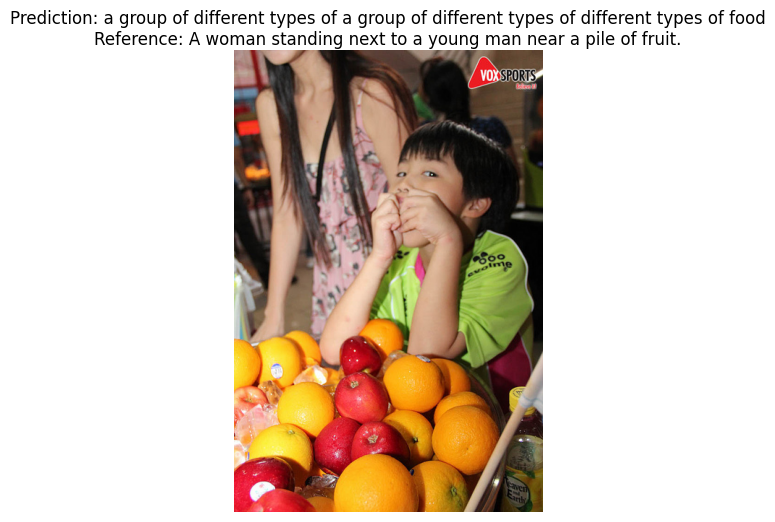

Prediction: a group of different types of a group of different types of different types of food
References:
- A woman standing next to a young man near a pile of fruit.
- A boy wearing a green shirt posing with some fruit.
- A young boy with his hands on his face near some fruit.
- A child with oranges and apples biting into one.
- a person leaning on a bunch of oranges and apples


'a group of different types of a group of different types of different types of food'

In [13]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state"]
)

model.eval()

print(
    "Loaded checkpoint from epoch:",
    checkpoint["epoch"]
)


@torch.no_grad()
def generate_caption(
    model,
    image_tensor,
    vocabulary,
    max_length=MAX_LENGTH
):
    model.eval()

    image_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )

    visual_tokens = model.encoder(
        image_tensor
    )

    generated = torch.tensor(
        [[vocabulary.sos_index]],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_length - 1):
        logits = model.decoder(
            visual_tokens,
            generated
        )

        next_index = (
            logits[:, -1, :]
            .argmax(dim=-1, keepdim=True)
        )

        generated = torch.cat(
            [generated, next_index],
            dim=1
        )

        if next_index.item() == vocabulary.eos_index:
            break

    return vocabulary.decode(
        generated[0].tolist()
    )


def show_prediction(index=None):
    if index is None:
        index = random.randrange(
            len(test_df)
        )

    row = test_df.iloc[index]

    raw_image = Image.open(
        IMAGE_DIR / row["image"]
    ).convert("RGB")

    prediction = generate_caption(
        model,
        eval_transform(raw_image),
        vocab
    )

    references = test_df[
        test_df["image_id"] == row["image_id"]
    ]["caption"].tolist()

    plt.figure(figsize=(8, 6))
    plt.imshow(raw_image)
    plt.axis("off")
    plt.title(
        f"Prediction: {prediction}\n"
        f"Reference: {references[0]}",
        wrap=True
    )
    plt.show()

    print("Prediction:", prediction)
    print("References:")

    for reference in references:
        print("-", reference)

    return prediction


show_prediction()


## 13. Show multiple test predictions


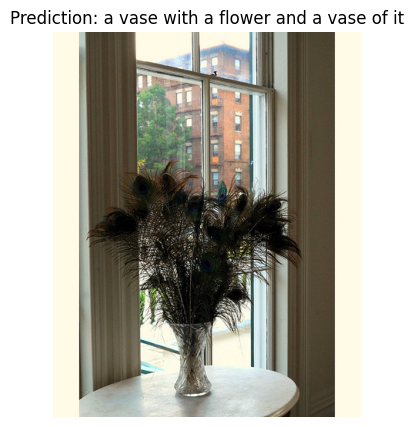

Prediction: a vase with a flower and a vase of it
Reference: A large glass vase with some flowers near a big window.
--------------------------------------------------------------------------------


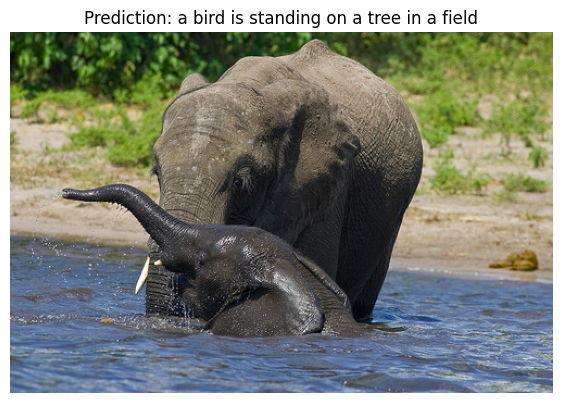

Prediction: a bird is standing on a tree in a field
Reference: A large elephant standing next to a small elephant playing in the water.
--------------------------------------------------------------------------------


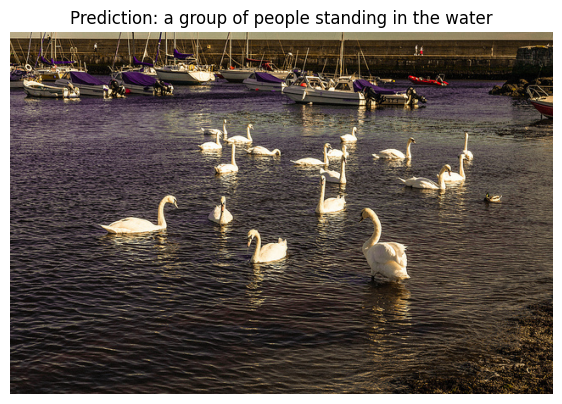

Prediction: a group of people standing in the water
Reference: A flock of swans swims in a bay.
--------------------------------------------------------------------------------


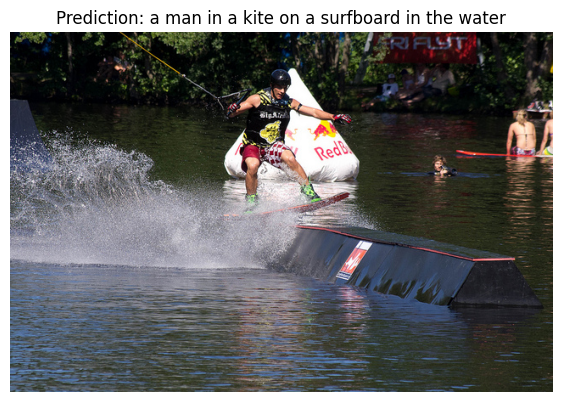

Prediction: a man in a kite on a surfboard in the water
Reference: a person riding a wake board on a body of water
--------------------------------------------------------------------------------


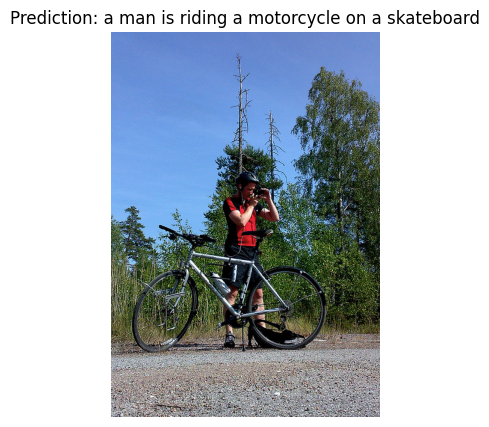

Prediction: a man is riding a motorcycle on a skateboard
Reference: A man wearing a bike helmet standing next to a bicycle.
--------------------------------------------------------------------------------


In [3]:
test_images = (
    test_df
    .drop_duplicates("image_id")
    .sample(
        n=min(5, test_df["image_id"].nunique()),
        random_state=SEED
    )
)

for row in test_images.itertuples(index=False):
    raw_image = Image.open(
        IMAGE_DIR / row.image
    ).convert("RGB")

    prediction = generate_caption(
        model,
        eval_transform(raw_image),
        vocab
    )

    references = test_df[
        test_df["image_id"] == row.image_id
    ]["caption"].tolist()

    plt.figure(figsize=(7, 5))
    plt.imshow(raw_image)
    plt.axis("off")
    plt.title(
        f"Prediction: {prediction}",
        wrap=True
    )
    plt.show()

    print("Prediction:", prediction)
    print("Reference:", references[0])
    print("-" * 80)


## 14. BLEU evaluation


In [ ]:
from nltk.translate.bleu_score import (
    corpus_bleu,
    SmoothingFunction
)


@torch.no_grad()
def evaluate_bleu(
    model,
    dataframe,
    max_images=200
):
    references = []
    hypotheses = []

    grouped = (
        dataframe
        .groupby(["image_id", "image"])["caption"]
        .apply(list)
        .reset_index()
        .head(max_images)
    )

    for row in tqdm(
        grouped.itertuples(index=False),
        total=len(grouped),
        desc="BLEU evaluation"
    ):
        raw_image = Image.open(
            IMAGE_DIR / row.image
        ).convert("RGB")

        prediction = generate_caption(
            model,
            eval_transform(raw_image),
            vocab
        )

        references.append([
            tokenize(caption)
            for caption in row.caption
        ])

        hypotheses.append(
            tokenize(prediction)
        )

    smoothing = SmoothingFunction().method1

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smoothing
    )

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing
    )

    return {
        "BLEU-1": bleu1,
        "BLEU-4": bleu4
    }


scores = evaluate_bleu(
    model,
    test_df
)

print(scores)


BLEU evaluation:   0%|          | 0/150 [00:00<?, ?it/s]

{'BLEU-1': 0.5862542955326461, 'BLEU-4': 0.1424665746559724}


## 15. Saved artifacts


In [ ]:
print("Checkpoint:", CHECKPOINT_PATH)
print("Vocabulary:", VOCAB_PATH)
print("Caption CSV:", CSV_PATH)

# In Colab, uncomment to download:
#
# from google.colab import files
# files.download(str(CHECKPOINT_PATH))
# files.download(str(VOCAB_PATH))


Checkpoint: /content/artifacts_vit_transformer/best_vit_transformer_model.pt
Vocabulary: /content/artifacts_vit_transformer/vocab.json
Caption CSV: /content/data/captions.csv


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

source = "/content/artifacts_vit_transformer/best_vit_transformer_model.pt"
destination_folder = "/content/drive/MyDrive/ImageCaptioningProject"

os.makedirs(destination_folder, exist_ok=True)

shutil.copy2(
    source,
    os.path.join(destination_folder, "best_vit_transformer_model.pt")
)

print("Model checkpoint backed up to Google Drive!")

Model checkpoint backed up to Google Drive!


In [ ]:
shutil.copy2(
    "/content/artifacts_vit_transformer/vocab.json",
    os.path.join(destination_folder, "vocab.json")
)

'/content/drive/MyDrive/ImageCaptioningProject/vocab.json'

In [2]:
import os
import shutil

source_folder = "/content/drive/MyDrive/ImageCaptioningProject"
destination_folder = "/content/artifacts_vit_transformer"

os.makedirs(destination_folder, exist_ok=True)

for filename in [
    "best_vit_transformer_model.pt",
    "vocab.json"
]:
    shutil.copy2(
        os.path.join(source_folder, filename),
        os.path.join(destination_folder, filename)
    )

print("Checkpoint and vocabulary restored!")

Checkpoint and vocabulary restored!
